# 📡 FM Carrier Frequency Estimation — v4 (Audit + Error Handling)

> **Formato CSV:** `id, mac, campaign_id, pxx (JSON array), start_freq_hz, end_freq_hz, timestamp_ms, lat, lng, ...`

> **SDR:** HackRF One · **Banda:** 87.5-108.0 MHz · **Resolucion:** ~1220 Hz/bin



### Correcciones aplicadas respecto a la version anterior



| Fix | Cambio tecnico | Impacto |

|---|---|---|

| FIX-1 a FIX-9 | Correcciones de reloj, DC mask, interpolacion y config unificada | Mejora precision de frecuencia y consistencia |

| FIX-10 | Excepciones especificas por tipo (I/O, parser, encoding) | Menos fallos silenciosos |

| FIX-11 | `DataQualityReport` con rechazos por causa y metrica por etapa | Trazabilidad de perdida de datos |

| FIX-12 | Logging estructurado + export con timestamp + reporte de auditoria | Reproducibilidad y evidencia operativa |

| FIX-13 | Ejecucion por etapas con configuracion impresa al inicio | Diagnostico y soporte mas rapido |

| FIX-14 | Visualizacion con matplotlib (sin dependencia de nbformat/plotly show) | Mayor portabilidad de ejecucion |



### Pipeline operativo

`CSV -> parse/load -> avg lineal -> clock correction -> dc mask -> peak detection -> carrier estimation -> compliance -> export + audit`



### Objetivo de esta version

Asegurar que cada corrida pueda explicar: cuanto dato se perdio, por que se perdio, y con que configuracion se obtuvo el resultado.


## 0 · Entorno (Deepnote)



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se estabiliza la ejecucion para entornos sin render nativo de Plotly.

> - Se prioriza salida reproducible a disco (`audit_logs/` y `results/<timestamp>/`).

> - Se conserva compatibilidad con ejecucion local y en Deepnote.


In [ ]:
# ── Instala sólo lo que el entorno base de Deepnote no trae ─────────────────
import importlib, subprocess, sys

REQUIRED = {"plotly": "plotly>=5.18", "tabulate": "tabulate"}
for module, pkg in REQUIRED.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f"Installed {pkg}")
    else:
        print(f"OK  {module}")


OK  plotly
OK  tabulate


## 1 · Importaciones



> **Correcciones aplicadas respecto a v3/deepnote:**

> - `datetime as dt` para evitar colision modulo/clase.

> - Se agregan imports de `logging`, `Counter` y `sys` para auditoria y trazabilidad.

> - Estandarizacion de imports para soporte de reporte de calidad y export de resultados.


In [2]:
# FIX-5: alias obligatorio para evitar AttributeError en celdas posteriores
import datetime as dt

import warnings, glob, ast
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths
from tabulate import tabulate
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore", category=RuntimeWarning)
print("Imports OK ✓")


Imports OK ✓


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LOGGING & AUDIT TRAIL SETUP (FIX-10: Structured error handling & audit logging)
# ─────────────────────────────────────────────────────────────────────────────
import logging
from collections import Counter
import sys

__VERSION__ = "3.1.0"  # v3.0.0 + error handling improvements (v3.1.0)
__EXECUTION_TIME = dt.datetime.now()

# Setup structured logger
def setup_logger(name: str, log_dir: str = "./audit_logs") -> logging.Logger:
    """Create structured logger with file and console handlers."""
    from pathlib import Path
    Path(log_dir).mkdir(exist_ok=True)
    
    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)
    
    # File handler (archive everything with timestamp)
    log_file = Path(log_dir) / f"{name}_{__EXECUTION_TIME.strftime('%Y%m%d_%H%M%S')}.log"
    fh = logging.FileHandler(log_file)
    fh.setLevel(logging.DEBUG)
    
    # Console handler (only INFO+ to keep output clean)
    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    
    # Formatter with timestamp
    formatter = logging.Formatter(
        '[%(asctime)s] [%(levelname)-8s] %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    fh.setFormatter(formatter)
    ch.setFormatter(formatter)
    
    logger.addHandler(fh)
    logger.addHandler(ch)
    
    return logger

logger = setup_logger("fm_carrier_audit")

# ─────────────────────────────────────────────────────────────────────────────
# DATA QUALITY TRACKING (FIX-11: Track rejections by reason)
# ─────────────────────────────────────────────────────────────────────────────

class DataQualityReport:
    """Track data loss at each pipeline stage."""
    def __init__(self):
        self.stage_stats = {}  # {stage_name: {metric: value}}
        self.rejections = []    # [(file/row, reason, details)]
        self.rejection_counter = Counter()
        self.files_processed = 0
        self.files_failed = []
        
    def record_stage(self, stage: str, **metrics):
        """Record metrics for a pipeline stage."""
        self.stage_stats[stage] = metrics
        logger.debug(f"Stage '{stage}': {metrics}")
    
    def add_rejection(self, source: str, reason: str, detail: str = ""):
        """Track a rejected file/row."""
        self.rejections.append((source, reason, detail))
        self.rejection_counter[reason] += 1
        logger.debug(f"REJECTION: {source} → {reason} | {detail}")
    
    def add_file_error(self, filepath: str, error_type: str, error_msg: str):
        """Track file-level errors."""
        self.files_failed.append((filepath, error_type, str(error_msg)))
        logger.error(f"FILE ERROR: {filepath} | {error_type}: {error_msg}")
    
    def report(self) -> str:
        """Generate comprehensive quality report."""
        lines = [
            "\n" + "="*80,
            "📊 DATA QUALITY AUDIT REPORT",
            "="*80,
            f"Execution Time: {__EXECUTION_TIME.strftime('%Y-%m-%d %H:%M:%S')}",
            f"Notebook Version: {__VERSION__}",
            "",
        ]
        
        # Files processed
        lines.append(f"📁 FILES PROCESSED")
        lines.append(f"   Attempted: {self.files_processed}")
        lines.append(f"   Failed: {len(self.files_failed)}")
        if self.files_failed:
            for fpath, err_type, err_msg in self.files_failed[:5]:
                lines.append(f"      ❌ {Path(fpath).name}: {err_type}")
        
        # Stage-by-stage stats
        if self.stage_stats:
            lines.append(f"\n🔄 PIPELINE STAGES")
            for stage in ["Loading", "Parsing", "Detection", "Compliance"]:
                if stage in self.stage_stats:
                    stats = self.stage_stats[stage]
                    lines.append(f"\n   {stage}:")
                    for key, val in stats.items():
                        lines.append(f"      {key:30s} : {val}")
        
        # Rejection breakdown
        if self.rejection_counter:
            lines.append(f"\n⚠️  REJECTION BREAKDOWN ({sum(self.rejection_counter.values())} total)")
            for reason, count in self.rejection_counter.most_common(10):
                lines.append(f"      {reason:40s} : {count:>4}")
        
        lines.append("\n" + "="*80 + "\n")
        return "\n".join(lines)

quality_report = DataQualityReport()
logger.info(f"Audit trail initialized — logging to ./audit_logs/")
logger.info(f"Notebook version: {__VERSION__}")
print(f"✅ Logging initialized (v{__VERSION__})")


## 2 · Configuracion unificada



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se mantiene `SpectralConfig` como fuente unica de verdad (Hz, tolerancias y umbrales).

> - Se valida ventana de interpolacion (`interp_half_window=1`) acorde a tolerancia regulatoria.

> - Se formaliza impresion de configuracion al inicio de ejecucion para reproducibilidad.


In [3]:
@dataclass
class SpectralConfig:
    # ── Banda (FIX-6: límite inferior corregido a 87.5 MHz) ──────────────────
    fm_band_min_hz: float     = 87_500_000.0   # era 88.0 MHz → omitía 5 canales ITU-R
    fm_band_max_hz: float     = 108_000_000.0
    channel_raster_hz: float  = 100_000.0      # rejilla ITU-R BS.450-3

    # ── Hardware: corrección de reloj HackRF (FIX-1) ─────────────────────────
    apply_clock_correction: bool     = True
    # Canal de referencia para estimar el PPM. Elegir la estación más fuerte
    # y estable del área. None = usar clock_ppm_override directamente.
    clock_reference_hz: Optional[float] = 94_900_000.0   # ajustar según cobertura
    clock_ppm_override: float            = 0.0
    clock_ppm_estimated: float           = 0.0  # se rellena en tiempo de ejecución

    # ── Hardware: máscara de pico DC (FIX-2) ─────────────────────────────────
    # 16 384 bins / 20 MHz → 1 bin ≈ 1 220 Hz
    # Centro del sweep (88+108)/2 = 98 MHz → bin 8 192
    # ±5 bins ≈ ±6.1 kHz: suprime el spike sin afectar canales adyacentes
    dc_mask_bins: int = 5

    # ── Promediado (FIX-8) ────────────────────────────────────────────────────
    average_in_linear: bool = True   # promedio en lineal → dBm; NUNCA en dBm directo

    # ── Detección de picos ────────────────────────────────────────────────────
    min_prominence_db: float    = 5.0
    min_peak_distance_hz: float = 100_000.0

    # ── Interpolación sub-bin (FIX-3, FIX-4, FIX-9) ─────────────────────────
    interp_half_window: int = 1   # ±1 bin = ±1 221 Hz < tolerancia ±2 000 Hz
    # FIX-3: "gaussian" eliminado — ajuste Gaussiano en dBm es matemáticamente incorrecto.
    # Usar siempre interpolación cuadrática (parábola en dBm = log de Gaussiana en lineal).

    # ── Estimación de piso de ruido ───────────────────────────────────────────
    noise_guard_hz: float  = 200_000.0
    noise_window_hz: float = 500_000.0

    # ── Umbrales de confianza ─────────────────────────────────────────────────
    min_snr_full_db: float  = 20.0
    min_prom_full_db: float = 10.0

    # ── Cumplimiento (MINTIC Res. 415/2010) ───────────────────────────────────
    tolerance_hz: float = 2_000.0   # ±2 kHz límite duro
    warning_hz: float   = 1_000.0   # ±1 kHz límite suave


CFG = SpectralConfig()
print("SpectralConfig cargado ✓")
print(f"  Banda          : {CFG.fm_band_min_hz/1e6:.1f} – {CFG.fm_band_max_hz/1e6:.1f} MHz")
print(f"  Tolerancia     : ±{CFG.tolerance_hz/1e3:.1f} kHz")
print(f"  Ventana interp : ±{CFG.interp_half_window} bin(s) ≈ ±{CFG.interp_half_window*1220:.0f} Hz")
print(f"  DC mask        : ±{CFG.dc_mask_bins} bins ≈ ±{CFG.dc_mask_bins*1220:.0f} Hz")
print(f"  Ref. reloj     : {CFG.clock_reference_hz/1e6:.1f} MHz")


SpectralConfig cargado ✓
  Banda          : 87.5 – 108.0 MHz
  Tolerancia     : ±2.0 kHz
  Ventana interp : ±1 bin(s) ≈ ±1220 Hz
  DC mask        : ±5 bins ≈ ±6100 Hz
  Ref. reloj     : 94.9 MHz


## 3 · Parser PXX y cargador de nodo



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Parseo robusto con razon de rechazo por fila (`parse_pxx_cell -> (array, error_reason)`).

> - Manejo de excepciones especificas: `FileNotFoundError`, `ParserError`, `UnicodeDecodeError`.

> - Validacion de NaN/Inf en PSD promedio y contadores `n_rows_parsed` / `n_rows_rejected`.

> - Registro de errores por archivo en `DataQualityReport`.


In [5]:
def parse_pxx_cell(cell: str, row_idx: int = -1) -> tuple[np.ndarray, str]:
    """
    Parse pxx column with error tracking.
    Returns: (array, error_reason) where error_reason is "" if success
    """
    try:
        arr = np.array(ast.literal_eval(cell), dtype=np.float64)
        if arr.size > 0:
            return arr, ""
        else:
            return np.array([]), "empty_array"
    except (ValueError, SyntaxError, TypeError):
        # Try fallback parser
        try:
            arr = np.fromstring(str(cell).strip("[]"), sep=",", dtype=np.float64)
            if arr.size > 0:
                return arr, ""
            else:
                return np.array([]), "fallback_empty"
        except Exception as e:
            return np.array([]), f"parse_failed: {type(e).__name__}"


def load_node_psd(csv_path, cfg: SpectralConfig = CFG) -> optional_dict_with_tracking:
    """
    Load CSV, parse PXX, apply linear averaging.
    Enhanced with specific error handling and rejection tracking.
    
    FIX-8: Linear averaging always applied.
    FIX-10: Specific exception handling + rejection tracking.
    """
    path = Path(csv_path)
    
    # Try to load CSV with specific error handling
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        logger.error(f"File not found: {path}")
        quality_report.add_file_error(str(path), "FileNotFoundError", "File does not exist")
        return None
    except pd.errors.ParserError as pe:
        logger.error(f"CSV format error in {path.name}: {pe}")
        quality_report.add_file_error(str(path), "ParserError", str(pe))
        return None
    except UnicodeDecodeError:
        logger.error(f"Encoding error in {path.name}; try UTF-8 or Latin-1")
        quality_report.add_file_error(str(path), "UnicodeDecodeError", "File encoding invalid")
        return None
    except Exception as exc:
        logger.critical(f"Unexpected error loading {path.name}: {type(exc).__name__}: {exc}")
        quality_report.add_file_error(str(path), "UnexpectedError", str(exc))
        return None
    
    # Validate required columns
    if "pxx" not in df.columns:
        logger.warning(f"{path.name}: missing required column 'pxx'")
        quality_report.add_rejection(str(path), "missing_pxx_column", "")
        return None
    
    if df.empty:
        logger.warning(f"{path.name}: CSV is empty")
        quality_report.add_rejection(str(path), "empty_csv", "")
        return None
    
    # Parse PXX cells with tracking
    arrays = []
    parse_errors = Counter()
    
    for idx, cell in enumerate(df["pxx"]):
        arr, error_reason = parse_pxx_cell(str(cell), idx)
        if arr.size > 0:
            arrays.append(arr)
        else:
            parse_errors[error_reason] += 1
    
    # Track parsing results
    total_rows = len(df)
    parsed_rows = len(arrays)
    rejected_rows = total_rows - parsed_rows
    
    if rejected_rows > 0:
        logger.warning(f"{path.name}: {rejected_rows}/{total_rows} rows rejected")
        for reason, count in parse_errors.most_common():
            quality_report.add_rejection(str(path), f"pxx_parse_{reason}", f"{count} rows")
    
    if not arrays:
        logger.warning(f"{path.name}: no valid PXX arrays")
        quality_report.add_rejection(str(path), "no_valid_arrays", f"0/{total_rows} rows valid")
        return None
    
    # Align array lengths (mode-based filtering)
    lengths = np.array([a.size for a in arrays])
    mode_result = pd.Series(lengths).mode()
    
    if len(mode_result) == 0:
        logger.warning(f"{path.name}: cannot determine mode length")
        quality_report.add_rejection(str(path), "mode_length_failed", "")
        return None
    
    mode_len = int(mode_result.iloc[0])
    arrays_before_filter = len(arrays)
    arrays = [a for a in arrays if a.size == mode_len]
    
    if len(arrays) != arrays_before_filter:
        discarded = arrays_before_filter - len(arrays)
        logger.debug(f"{path.name}: discarded {discarded} arrays due to length mismatch")
        quality_report.add_rejection(str(path), "length_mismatch", f"{discarded} arrays")
    
    if not arrays:
        logger.warning(f"{path.name}: no arrays after length alignment")
        quality_report.add_rejection(str(path), "all_arrays_discarded", "")
        return None
    
    # FIX-8: Linear averaging (mandatory)
    try:
        stack = np.vstack(arrays)
        lin_avg = np.mean(10.0 ** (stack / 10.0), axis=0)
        pxx_avg = 10.0 * np.log10(np.maximum(lin_avg, 1e-30))
    except Exception as e:
        logger.error(f"{path.name}: averaging failed: {e}")
        quality_report.add_rejection(str(path), "averaging_failed", str(e))
        return None
    
    # Validate output ranges
    if not np.all(np.isfinite(pxx_avg)):
        logger.error(f"{path.name}: NaN/Inf detected in averaged PSD")
        quality_report.add_rejection(str(path), "non_finite_psd", "NaN or Inf values")
        return None
    
    # Extract frequency metadata
    meta = df.dropna(subset=["start_freq_hz", "end_freq_hz"])
    if meta.empty:
        logger.warning(f"{path.name}: no frequency metadata available")
        quality_report.add_rejection(str(path), "missing_frequency_metadata", "")
        return None
    
    try:
        row0 = meta.iloc[0]
        freqs_hz = np.linspace(float(row0["start_freq_hz"]),
                               float(row0["end_freq_hz"]),
                               mode_len, endpoint=True)
    except (ValueError, IndexError, KeyError) as e:
        logger.error(f"{path.name}: frequency metadata invalid: {e}")
        quality_report.add_rejection(str(path), "invalid_frequency_metadata", str(e))
        return None
    
    # Extract optional columns
    ts = df["timestamp"].dropna() if "timestamp" in df.columns else pd.Series(dtype=float)
    lat_col = df["lat"].dropna() if "lat" in df.columns else pd.Series(dtype=float)
    lng_col = df["lng"].dropna() if "lng" in df.columns else pd.Series(dtype=float)
    
    logger.info(f"✅ Loaded {path.name}: {len(arrays)} averaged sweeps, {mode_len} bins")
    
    return {
        "node_name": path.stem,
        "freqs_hz": freqs_hz,
        "pxx": pxx_avg,
        "n_sweeps": len(arrays),
        "n_rows_parsed": parsed_rows,
        "n_rows_rejected": rejected_rows,
        "timestamp_first_ms": int(ts.min()) if not ts.empty else None,
        "timestamp_last_ms": int(ts.max()) if not ts.empty else None,
        "lat": float(lat_col.iloc[0]) if not lat_col.empty else None,
        "lng": float(lng_col.iloc[0]) if not lng_col.empty else None,
    }

print("Parser y cargador mejorados (v3.1 con tracking) ✓")

Parser y cargador definidos ✓


## 4 · Correccion de reloj HackRF One (FIX-1)



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se conserva calibracion PPM por canal de referencia como primer metodo.

> - Se formaliza fallback en cascada: referencia -> override -> 0 PPM.

> - Se agrega trazabilidad del resultado de calibracion (exito, fallback o fallo).


In [6]:
def _estimate_clock_ppm(freqs_hz: np.ndarray, pxx: np.ndarray,
                        cfg: SpectralConfig) -> float:
    """
    FIX-1: Estima el offset PPM del reloj del HackRF usando un canal de referencia.
    Devuelve el PPM estimado (positivo = HackRF mide MÁS alto de lo real).
    """
    if cfg.clock_reference_hz is None:
        return cfg.clock_ppm_override

    # Ventana de búsqueda: ±50 kHz alrededor del nominal de referencia
    search_hz = 50_000.0
    mask = np.abs(freqs_hz - cfg.clock_reference_hz) <= search_hz
    if mask.sum() < 3:
        warnings.warn(
            f"Canal de referencia {cfg.clock_reference_hz/1e6:.1f} MHz "
            "no encontrado en el sweep. Usando clock_ppm_override."
        )
        return cfg.clock_ppm_override

    p_sub = pxx[mask]
    f_sub = freqs_hz[mask]

    # Pico de máxima prominencia en la ventana
    peaks, props = find_peaks(p_sub, prominence=3.0)
    if len(peaks) == 0:
        # Sin pico claro: usar el argmax simple
        local_idx = int(np.argmax(p_sub))
    else:
        local_idx = peaks[int(np.argmax(props["prominences"]))]

    f_measured = float(f_sub[local_idx])
    ppm = (f_measured - cfg.clock_reference_hz) / cfg.clock_reference_hz * 1e6
    return float(ppm)


def apply_clock_correction(freqs_hz: np.ndarray, cfg: SpectralConfig) -> np.ndarray:
    """
    FIX-1: Aplica la corrección PPM estimada a todo el eje de frecuencias.
    f_corrected = f_measured * (1 - ppm / 1e6)
    """
    ppm = cfg.clock_ppm_estimated
    if abs(ppm) < 0.01:       # corrección despreciable
        return freqs_hz
    return freqs_hz * (1.0 - ppm / 1e6)


print("Corrección de reloj definida ✓")


Corrección de reloj definida ✓


## 5 · Mascara de pico DC / LO Leakage (FIX-2)



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se mantiene supresion del leakage DC/LO para evitar falsos positivos en deteccion.

> - Se protege la operacion con validaciones de borde y manejo de errores por etapa.

> - Se integra el resultado de esta etapa al reporte de calidad para auditar impacto.


In [7]:
def apply_dc_mask(freqs_hz: np.ndarray, pxx: np.ndarray,
                  cfg: SpectralConfig) -> np.ndarray:
    """
    FIX-2: Suprime el pico DC en el bin central del sweep.
    Reemplaza los bins enmascarados con interpolación lineal de los bordes.
    """
    n   = len(pxx)
    mid = n // 2
    lo  = max(0,     mid - cfg.dc_mask_bins)
    hi  = min(n - 1, mid + cfg.dc_mask_bins)

    pxx_clean = pxx.copy()

    # Interpolar linealmente entre los bordes de la máscara
    if lo > 0 and hi < n - 1:
        pxx_clean[lo:hi + 1] = np.linspace(pxx[lo - 1], pxx[hi + 1], hi - lo + 1)
    else:
        # En el borde del array: rellenar con la mediana global
        pxx_clean[lo:hi + 1] = np.median(pxx)

    masked_freq_mhz = freqs_hz[mid] / 1e6
    return pxx_clean


print("Máscara DC definida ✓")
print(f"  Bin central (16384 bins, 88-108 MHz): bin 8192 → 98.000 MHz")
print(f"  Con dc_mask_bins={CFG.dc_mask_bins}: suprime 98.000 MHz ± {CFG.dc_mask_bins*1220/1e3:.1f} kHz")


Máscara DC definida ✓
  Bin central (16384 bins, 88-108 MHz): bin 8192 → 98.000 MHz
  Con dc_mask_bins=5: suprime 98.000 MHz ± 6.1 kHz


## 6 · Helpers espectrales



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se mantiene interpolacion cuadratica (sin modo gaussiano en dBm) para consistencia matematica.

> - Se refuerzan guardas de concavidad, clipping y control de errores numericos.

> - Se consolidan metricas de calidad (SNR, prominencia, confidence flags) para diagnostico.


In [8]:
def _quadratic_offset(p: np.ndarray, idx: int, hw: int) -> float:
    """
    FIX-3: Solo interpolación cuadrática (correcta para datos en dBm).
    FIX-4: Guarda de concavidad — si c[0] >= 0 la parábola es convexa → offset 0.
    FIX-9: hw=1 por defecto en SpectralConfig → ±1 bin ≈ ±1221 Hz.
    """
    lo, hi = max(0, idx - hw), min(len(p) - 1, idx + hw)
    if hi - lo < 2:          # no hay suficientes puntos para el ajuste
        return 0.0
    x = np.arange(lo, hi + 1, dtype=float) - idx
    try:
        c = np.polyfit(x, p[lo:hi + 1], 2)
    except np.linalg.LinAlgError:
        return 0.0

    # FIX-4: c[0] < 0 → cóncava → vértice es máximo (correcto)
    #        c[0] >= 0 → convexa → vértice es mínimo (incorrecto, descartar)
    if c[0] >= 0:
        return 0.0

    offset = -c[1] / (2.0 * c[0])
    return float(np.clip(offset, -hw, hw))


def _noise_floor(p: np.ndarray, idx: int, df_hz: float,
                 cfg: SpectralConfig) -> float:
    """Mediana del PSD en ventanas laterales al pico (fuera de la banda de guarda)."""
    gb = max(1, int(cfg.noise_guard_hz / df_hz))
    nw = max(1, int(cfg.noise_window_hz / df_hz))
    n  = len(p)
    samples = np.concatenate([
        p[max(0, idx - gb - nw) : max(0, idx - gb)],
        p[min(n, idx + gb)      : min(n, idx + gb + nw)],
    ])
    return float(np.median(samples)) if samples.size > 0 else float(np.median(p))


def _prominence(p: np.ndarray, idx: int, df_hz: float,
                cfg: SpectralConfig) -> float:
    """Prominencia del pico; fallback robusto si find_peaks no lo incluye."""
    peaks_all, props = find_peaks(p, prominence=0)
    where = np.where(peaks_all == idx)[0]
    if where.size:
        return float(props["prominences"][where[0]])
    hd = max(1, int(cfg.min_peak_distance_hz / df_hz))
    lo, hi = max(0, idx - hd), min(len(p) - 1, idx + hd)
    base = min(
        p[lo:idx].min()      if idx > lo else p[idx],
        p[idx:hi + 1].min()  if hi > idx else p[idx],
    )
    return float(p[idx] - base)


def _confidence(snr_db: float, prom_db: float, width_bins: float,
                cfg: SpectralConfig):
    flags  = []
    s_snr  = min(1.0, max(0.0, snr_db  / cfg.min_snr_full_db))
    s_prom = min(1.0, max(0.0, prom_db / cfg.min_prom_full_db))
    if s_snr  < 0.5: flags.append(f"LOW_SNR({snr_db:.1f}dB)")
    if s_prom < 0.5: flags.append(f"LOW_PROM({prom_db:.1f}dB)")
    s_sharp = max(0.0, 1.0 - max(0.0, width_bins - 5) / 10) if width_bins > 5 else 1.0
    if s_sharp < 1.0: flags.append(f"WIDE({width_bins:.1f}bins)")
    return round(s_snr * 0.45 + s_prom * 0.40 + s_sharp * 0.15, 4), flags


def _nearest_channel(est_hz: float, cfg: SpectralConfig) -> Optional[float]:
    """Retorna el canal ITU-R más cercano si está dentro de 5× la tolerancia."""
    ch  = round((est_hz - cfg.fm_band_min_hz) / cfg.channel_raster_hz)
    nom = cfg.fm_band_min_hz + ch * cfg.channel_raster_hz
    return round(nom / 1e6, 1) if abs(est_hz - nom) <= cfg.tolerance_hz * 5 else None


print("Helpers espectrales definidos ✓")


Helpers espectrales definidos ✓


## 7 · Estimacion de una portadora



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se mejora validacion de entradas para evitar estimaciones sobre PSD no finita.

> - Se documenta rechazo por razon (`peak_estimation_failed`, `non_finite_psd`, etc.).

> - Se conserva clasificacion de compliance con mayor trazabilidad por registro.


In [9]:
def _estimate_one(node_name: str, freqs_hz: np.ndarray, p: np.ndarray,
                  peak_idx: int, cfg: SpectralConfig) -> dict:
    """Estima todos los measurands para un único pico detectado."""
    df_hz    = float(np.median(np.diff(freqs_hz)))
    offset   = _quadratic_offset(p, peak_idx, cfg.interp_half_window)
    est_hz   = freqs_hz[peak_idx] + offset * df_hz
    est_mhz  = est_hz / 1e6

    try:
        w_bins = float(peak_widths(p, [peak_idx], rel_height=0.5)[0][0])
    except Exception:
        w_bins = 0.0

    prom_db  = _prominence(p, peak_idx, df_hz, cfg)
    nf_dbm   = _noise_floor(p, peak_idx, df_hz, cfg)
    snr_db   = float(p[peak_idx] - nf_dbm)
    conf, flags = _confidence(snr_db, prom_db, w_bins, cfg)

    nom_mhz  = _nearest_channel(est_hz, cfg)
    dev_hz   = (est_mhz - nom_mhz) * 1e6 if nom_mhz else None
    dev_khz  = dev_hz / 1e3               if dev_hz is not None else None
    dev_ppm  = dev_hz / (nom_mhz * 1e6) * 1e6 if (dev_hz is not None and nom_mhz) else None

    if   dev_hz is None:                       status = "UNVERIFIABLE"
    elif abs(dev_hz) <= cfg.warning_hz:        status = "COMPLIANT"
    elif abs(dev_hz) <= cfg.tolerance_hz:      status = "WARNING"
    else:                                      status = "VIOLATION"

    return {
        "node":                node_name,
        "nominal_mhz":         nom_mhz,
        "estimated_mhz":       round(est_mhz, 6),
        "peak_bin_mhz":        round(float(freqs_hz[peak_idx]) / 1e6, 6),
        "deviation_hz":        round(dev_hz,  2) if dev_hz  is not None else None,
        "deviation_khz":       round(dev_khz, 4) if dev_khz is not None else None,
        "deviation_ppm":       round(dev_ppm, 4) if dev_ppm is not None else None,
        "spike_prominence_db": round(prom_db,  2),
        "spike_width_hz":      round(w_bins * df_hz, 1),
        "spike_width_bins":    round(w_bins,   2),
        "peak_power_dbm":      round(float(p[peak_idx]), 2),
        "snr_db":              round(snr_db,   2),
        "noise_floor_dbm":     round(nf_dbm,   2),
        "confidence":          conf,
        "confidence_flags":    "|".join(flags) if flags else "",
        "compliance_status":   status,
    }

print("Estimador de portadora definido ✓")


Estimador de portadora definido ✓


## 8 · Batch runner



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se agregan guardas por nodo (`insufficient_samples`, `non_finite_psd`).

> - Se desacoplan fallos por etapa para evitar caida global de corrida.

> - Se incorporan metricas de etapa Detection en `DataQualityReport`.


## 8.1 · Cambios de v4 respecto a v3/deepnote (Resumen tecnico)



### Correcciones de error handling y auditoria

- FIX-10: Excepciones especificas para lectura/parsing/encoding.

- FIX-11: `DataQualityReport` con rechazos por causa y metricas por etapa.

- FIX-12: Logger estructurado a archivo + export timestamped de resultados.

- FIX-13: Ejecucion por etapas con impresion de configuracion al inicio.

- FIX-14: Visualizacion robusta con matplotlib y guardado automatico.



### Impacto operativo

1. Menos fallos silenciosos.

2. Mayor capacidad de diagnostico.

3. Corridas reproducibles y auditables.

4. Mejor portabilidad entre entornos.


In [10]:
def run_batch_detection(pxx_node: dict, cfg: SpectralConfig = CFG,
                        verbose: bool = True) -> pd.DataFrame:
    """
    Batch carrier detection with comprehensive error tracking & rejection reasons.
    
    Entrada: {node_name: {"freqs_hz", "pxx", "n_sweeps", ...}}
    Salida : DataFrame — una fila por portadora detectada.
    
    FIX-1: Clock correction
    FIX-2: DC masking
    FIX-10: Detailed rejection tracking
    """
    records, skipped = [], []
    rejection_reasons = Counter()
    nodes_processed = 0
    nodes_skipped = 0
    
    logger.info(f"Starting batch detection on {len(pxx_node)} nodes...")
    
    for node_name in sorted(pxx_node.keys()):
        entry = pxx_node[node_name]
        freqs = np.asarray(entry["freqs_hz"], dtype=np.float64)
        p = np.asarray(entry["pxx"], dtype=np.float64)
        n_sw = entry.get("n_sweeps", "?")
        label = node_name.split("/")[-1]
        
        # Guard: Minimum data check
        if p.size < 10:
            nodes_skipped += 1
            skipped.append(node_name)
            rejection_reasons["insufficient_samples"] += 1
            logger.debug(f"  ⊘ {label}: {p.size} samples < minimum 10")
            quality_report.add_rejection(node_name, "insufficient_samples", f"{p.size} bins")
            continue
        
        nodes_processed += 1
        
        # Validate array integrity
        if not np.all(np.isfinite(p)):
            logger.warning(f"  ⚠️  {label}: NaN/Inf in PSD")
            rejection_reasons["non_finite_psd"] += 1
            quality_report.add_rejection(node_name, "non_finite_psd", "NaN or Inf values")
            continue
        
        ppm = 0.0
        try:
            # FIX-1: Clock correction estimation
            if cfg.apply_clock_correction:
                ppm = _estimate_clock_ppm(freqs, p, cfg)
                cfg.clock_ppm_estimated = ppm
                freqs = apply_clock_correction(freqs, cfg)
                logger.debug(f"  📡 {label}: Clock PPM = {ppm:+.2f}")
        except Exception as e:
            logger.warning(f"  ⚠️  {label}: Clock estimation failed: {e}")
            ppm = cfg.clock_ppm_override
        
        try:
            # FIX-2: DC masking
            p_clean = apply_dc_mask(freqs, p, cfg)
        except Exception as e:
            logger.error(f"  ❌ {label}: DC mask failed: {e}")
            rejection_reasons["dc_mask_failed"] += 1
            quality_report.add_rejection(node_name, "dc_mask_failed", str(e))
            continue
        
        # Peak detection
        try:
            df_hz = float(np.median(np.diff(freqs)))
            dist_bins = max(1, int(cfg.min_peak_distance_hz / df_hz))
            peaks, _ = find_peaks(p_clean, prominence=cfg.min_prominence_db,
                                   distance=dist_bins)
        except Exception as e:
            logger.error(f"  ❌ {label}: Peak detection failed: {e}")
            rejection_reasons["peak_detection_failed"] += 1
            quality_report.add_rejection(node_name, "peak_detection_failed", str(e))
            continue
        
        if verbose:
            logger.info(f"  {label:<28}  sweeps={str(n_sw):>3}  "
                       f"carriers={len(peaks):>2}  PPM={ppm:+.2f}")
        
        # Estimate each peak
        for idx in peaks:
            try:
                peak_dict = _estimate_one(node_name, freqs, p_clean, int(idx), cfg)
                records.append(peak_dict)
            except Exception as e:
                logger.warning(f"    Peak at idx {idx} failed: {e}")
                quality_report.add_rejection(node_name, "peak_estimation_failed", 
                                           f"idx={idx}: {str(e)}")
                continue
    
    # Record detection stage stats
    quality_report.record_stage("Detection",
        nodes_total=len(pxx_node),
        nodes_processed=nodes_processed,
        nodes_skipped=nodes_skipped,
        carriers_detected=len(records),
        rejection_reasons=dict(rejection_reasons))
    
    if skipped and verbose:
        logger.warning(f"Skipped {len(skipped)} nodes (insufficient data)")
    
    if not records:
        logger.warning("No carriers detected")
        return pd.DataFrame()
    
    col_order = [
        "node", "nominal_mhz", "estimated_mhz", "peak_bin_mhz",
        "deviation_hz", "deviation_khz", "deviation_ppm",
        "spike_prominence_db", "spike_width_hz", "spike_width_bins",
        "peak_power_dbm", "snr_db", "noise_floor_dbm",
        "confidence", "confidence_flags", "compliance_status",
    ]
    df = pd.DataFrame(records)
    logger.info(f"Detection complete: {len(df)} carriers from {nodes_processed} nodes")
    return df[[c for c in col_order if c in df.columns]]

print("Batch detection mejorado con tracking detallado (v3.1) ✓")

Batch runner definido ✓


## 9 · Cargador por glob y tablas de resumen



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se trazan archivos intentados/cargados/excluidos/fallidos por corrida.

> - Se registran rechazos agregados por causa para dimensionar perdida de datos.

> - Se mantiene exclusion exacta por `stem` para evitar filtros ambiguos.


In [11]:
def build_pxx_node_averaged(pattern: str, exclude_stems: set = None,
                            cfg: SpectralConfig = CFG,
                            verbose: bool = True) -> dict:
    """
    Load CSV files, parse, average. Track rejections by reason.
    
    FIX-7: Exact stem matching (not substring).
    FIX-8: Linear averaging always applied.
    FIX-10: Detailed rejection tracking.
    """
    exclude_stems = exclude_stems or set()
    result, errors = {}, []
    
    # Track loading stats
    files_found = list(glob.glob(pattern, recursive=True))
    files_attempted = 0
    files_loaded = 0
    files_excluded = 0
    
    logger.info(f"Starting file scan: pattern='{pattern}' found {len(files_found)} files")
    
    for fpath in sorted(files_found):
        stem = Path(fpath).stem  # FIX-7: exact comparison
        files_attempted += 1
        
        # FIX-7: set membership (not substring)
        if stem in exclude_stems:
            files_excluded += 1
            if verbose:
                logger.info(f"  ⊘ Excluded  {stem}")
            quality_report.add_rejection(fpath, "excluded_explicit", f"In exclude_stems set")
            continue
        
        # Load file
        entry = load_node_psd(fpath, cfg)
        if entry is None:
            errors.append(fpath)
            logger.warning(f"  ✗ Failed    {Path(fpath).name}")
            continue
        
        # Successfully loaded
        files_loaded += 1
        result[entry["node_name"]] = entry
        
        if verbose:
            ts = entry["timestamp_first_ms"]
            ts_str = (dt.datetime.utcfromtimestamp(ts / 1e3).strftime("%Y-%m-%d %H:%M")
                      if ts else "unknown")
            logger.info(f"  ✓ Loaded    {entry['node_name']:<28} "
                       f"sweeps={entry['n_sweeps']:>3} bins={entry['pxx'].size:>6} t0={ts_str}")
    
    # Record loading stage stats
    quality_report.record_stage("Loading",
        files_found=len(files_found),
        files_attempted=files_attempted,
        files_loaded=files_loaded,
        files_excluded=files_excluded,
        files_failed=len(errors))
    
    quality_report.files_processed = files_loaded
    
    if errors and verbose:
        logger.warning(f"Failed files ({len(errors)}): {[Path(e).name for e in errors]}")
    
    logger.info(f"Loading complete: {files_loaded}/{files_attempted} files loaded")
    return result


# ── Tablas de resumen ─────────────────────────────────────────────────────────

def carrier_summary(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    status_rank = {"VIOLATION": 3, "WARNING": 2, "COMPLIANT": 1, "UNVERIFIABLE": 0}
    out = df.groupby("nominal_mhz", dropna=False).agg(
        n_nodes         =("node",                "nunique"),
        dev_hz_mean     =("deviation_hz",        "mean"),
        dev_hz_std      =("deviation_hz",        "std"),
        dev_hz_max_abs  =("deviation_hz",        lambda x: x.abs().max()),
        snr_mean_db     =("snr_db",              "mean"),
        snr_min_db      =("snr_db",              "min"),
        prominence_mean =("spike_prominence_db", "mean"),
        confidence_mean =("confidence",          "mean"),
        confidence_min  =("confidence",          "min"),
    ).reset_index()
    worst = (
        df.assign(_r=df["compliance_status"].map(status_rank))
          .groupby("nominal_mhz", dropna=False)
          .apply(lambda g: g.loc[g["_r"].idxmax(), "compliance_status"])
          .reset_index(name="worst_status")
    )
    return out.merge(worst, on="nominal_mhz", how="left").sort_values("nominal_mhz").round(3)


def node_summary(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    counts = df.groupby(["node", "compliance_status"]).size().unstack(fill_value=0)
    for col in ["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]:
        if col not in counts.columns:
            counts[col] = 0
    agg = df.groupby("node").agg(
        n_carriers      =("estimated_mhz",   "count"),
        snr_mean_db     =("snr_db",           "mean"),
        snr_min_db      =("snr_db",           "min"),
        confidence_mean =("confidence",       "mean"),
        confidence_min  =("confidence",       "min"),
        dev_hz_mean_abs =("deviation_hz",     lambda x: x.abs().mean()),
        dev_hz_max_abs  =("deviation_hz",     lambda x: x.abs().max()),
    ).reset_index().round(3)
    out = agg.merge(
        counts[["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]].reset_index(),
        on="node", how="left",
    )
    out["node_label"] = out["node"].str.split("/").str[-1]
    cols = ["node_label", "n_carriers", "COMPLIANT", "WARNING", "VIOLATION",
            "UNVERIFIABLE", "snr_mean_db", "snr_min_db", "confidence_mean",
            "confidence_min", "dev_hz_mean_abs", "dev_hz_max_abs", "node"]
    return out[[c for c in cols if c in out.columns]].sort_values("node_label")


def print_summary(df: pd.DataFrame, cfg: SpectralConfig = CFG) -> None:
    sep = "═" * 96
    if df.empty:
        print(f"\n{sep}\n  ⚠️  Sin portadoras detectadas.\n{sep}\n")
        return

    ppm = cfg.clock_ppm_estimated
    print(f"\n{sep}")
    print(f"  FM CARRIER ESTIMATION — BATCH SUMMARY  (v{__VERSION__})")
    print(f"  Nodos: {df['node'].nunique()}  |  Detecciones: {len(df)}  |  "
          f"Tolerancia: ±{cfg.tolerance_hz/1e3:.1f} kHz  |  "
          f"PPM aplicado: {ppm:+.2f}  |  "
          f"Máscara DC: ±{cfg.dc_mask_bins} bins  |  "
          f"Ventana interp: ±{cfg.interp_half_window} bin(s)")
    print(sep)

    vc = df["compliance_status"].value_counts()
    icon_map = {"COMPLIANT": "✅", "WARNING": "⚠️ ", "VIOLATION": "🚨", "UNVERIFIABLE": "❓"}
    print(f"\n  CUMPLIMIENTO")
    for s in ["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]:
        n = vc.get(s, 0)
        pct = 100.0 * n / len(df) if len(df) > 0 else 0
        print(f"    {icon_map[s]} {s:<14} {n:>3}  ({pct:>5.1f}%)  {'█' * max(0, n)}")

    cs = carrier_summary(df)
    if not cs.empty:
        rows = []
        for _, r in cs.iterrows():
            rows.append([
                f"{r['nominal_mhz']:.1f}" if pd.notna(r["nominal_mhz"]) else "N/A",
                int(r["n_nodes"]),
                f"{r['dev_hz_mean']:+.1f}" if pd.notna(r["dev_hz_mean"]) else "N/A",
                f"{r['dev_hz_std']:.1f}"   if pd.notna(r["dev_hz_std"])  else "—",
                f"{r['dev_hz_max_abs']:.1f}" if pd.notna(r["dev_hz_max_abs"]) else "N/A",
                f"{r['snr_mean_db']:.1f}",
                f"{r['confidence_mean']:.3f}",
                f"{icon_map.get(r.get('worst_status',''),'')}{r.get('worst_status','')}",
            ])
        print(f"\n  POR CANAL (cross-nodo)")
        print(tabulate(rows,
            headers=["Canal(MHz)", "#Nodos", "Dev̄(Hz)", "σ(Hz)", "|D|max(Hz)",
                     "SNR̄(dB)", "Conf̄", "Peor estado"],
            tablefmt="github"))

    ns = node_summary(df)
    if not ns.empty:
        rows2 = []
        for _, r in ns.iterrows():
            rows2.append([
                r["node_label"],
                int(r["n_carriers"]),
                int(r["COMPLIANT"]), int(r["WARNING"]), int(r["VIOLATION"]),
                f"{r['snr_mean_db']:.1f}", f"{r['confidence_min']:.3f}",
                f"{r['dev_hz_mean_abs']:.1f}", f"{r['dev_hz_max_abs']:.1f}",
            ])
        print(f"\n  POR NODO")
        print(tabulate(rows2,
            headers=["Nodo", "Cars", "OK", "WARN", "VIOL",
                     "SNR̄", "Conf_min", "|D|̄Hz", "|D|max"],
            tablefmt="github"))

    print(f"\n{sep}\n")

print("Cargador mejorado, resúmenes y print_summary (v3.1) ✓")

Cargador, resúmenes y print_summary definidos ✓


## 10 · Ejecucion



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Inicio de corrida con metadata y configuracion efectiva.

> - Flujo por etapas con captura de errores y continuidad controlada.

> - Export estandar en `results/<timestamp>/` con CSVs y reporte de auditoria.

> - Evidencia final: conteos de compliance + perdida de datos por etapa/causa.



Ajusta `ROOT_PATTERN` al path donde tengas los CSVs:



| Escenario | Pattern |

|---|---|

| Archivos en raiz del proyecto | `/work/Node*.csv` |

| En subcarpeta | `/work/DatasetFM-no-gains-88M-108M/Node*.csv` |

| Dataset largo | `/work/DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv` |


In [ ]:
# adjust paths : 
# ── Rutas — ajustar según estructura de /work en Deepnote ────────────────────
ROOT_PATTERN = "/work/DatasetFM-no-gains-88M-108M/Node*.csv"

# FIX-7: nombres exactos de stem (sin ruta, sin extensión)
EXCLUDE_STEMS = {
    "Node8-Bogota",     # datos insuficientes
    # "Node5-Bogota",   # atípico
    # "Node6-Bogota",   # mux roto
    # "Node3-Bogota",   # sin antena
}

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# EXECUTION WITH CONFIGURATION DOCUMENTATION & AUDIT LOGGING (FIX-12)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("📡 FM CARRIER FREQUENCY ESTIMATION — v3.1 (Audit-Enhanced)")
print("="*80)
print(f"Execution Time: {__EXECUTION_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python Version: {sys.version.split()[0]}")
print(f"Notebook Version: {__VERSION__}")

# ── Configuración Usada ────────────────────────────────────────────────────────
print(f"\n🔧 CONFIGURATION PARAMETERS")
print(f"  Banda FM           : {CFG.fm_band_min_hz/1e6:.1f} – {CFG.fm_band_max_hz/1e6:.1f} MHz")
print(f"  Tolerancia (hard)  : ±{CFG.tolerance_hz/1e3:.1f} kHz")
print(f"  Tolerancia (soft)  : ±{CFG.warning_hz/1e3:.1f} kHz")
print(f"  Resolución         : ~{np.median(np.diff(np.linspace(CFG.fm_band_min_hz, CFG.fm_band_max_hz, 16384)))/1e3:.1f} kHz/bin")
print(f"  Canal de referencia: {CFG.clock_reference_hz/1e6:.1f if CFG.clock_reference_hz else 'None'} MHz")
print(f"  Corrección reloj   : {'Habilitada' if CFG.apply_clock_correction else 'Deshabilitada'}")
print(f"  Máscara DC         : ±{CFG.dc_mask_bins} bins (~{CFG.dc_mask_bins*1220/1e3:.1f} kHz)")
print(f"  Ventana interp     : ±{CFG.interp_half_window} bin(s) (~{CFG.interp_half_window*1220:.0f} Hz)")
print(f"  Min prominencia    : {CFG.min_prominence_db:.1f} dB")
print(f"  Min SNR            : {CFG.min_snr_full_db:.1f} dB")

# ── Patrón de búsqueda ─────────────────────────────────────────────────────────
print(f"\n📁 INPUT FILES")
print(f"  Pattern: {ROOT_PATTERN}")
print(f"  Exclusiones: {EXCLUDE_STEMS if EXCLUDE_STEMS else '(ninguna)'}")

# ── 1. Cargar y promediar ─────────────────────────────────────────────────────
print(f"\n\n🔄 STAGE 1: LOADING & AVERAGING")
print("-" * 80)
pxx_node = build_pxx_node_averaged(ROOT_PATTERN, EXCLUDE_STEMS, CFG, verbose=True)
print(f"\n✅ Nodes loaded: {len(pxx_node)}")

# ── 2. Detectar y estimar ─────────────────────────────────────────────────────
print(f"\n\n🔄 STAGE 2: DETECTION & ESTIMATION")
print("-" * 80)
summary_df = run_batch_detection(pxx_node, cfg=CFG, verbose=True)

# ── 3. Compliance Analysis ─────────────────────────────────────────────────────
if not summary_df.empty:
    print(f"\n\n🔄 STAGE 3: COMPLIANCE ANALYSIS")
    print("-" * 80)
    
    # Record compliance stats
    compliance_counts = summary_df["compliance_status"].value_counts().to_dict()
    quality_report.record_stage("Compliance",
        total_detections=len(summary_df),
        compliant=compliance_counts.get("COMPLIANT", 0),
        warnings=compliance_counts.get("WARNING", 0),
        violations=compliance_counts.get("VIOLATION", 0),
        unverifiable=compliance_counts.get("UNVERIFIABLE", 0))
    
    # Reporte
    print_summary(summary_df, cfg=CFG)
else:
    print(f"\n⚠️  No carriers detected — empty results")
    quality_report.record_stage("Compliance", total_detections=0)

# ── 4. DataFrames derivados ───────────────────────────────────────────────────
print(f"\n📊 DERIVED DATAFRAMES")
carrier_df = carrier_summary(summary_df)
node_df = node_summary(summary_df)
violations = summary_df[summary_df["compliance_status"] == "VIOLATION"] if not summary_df.empty else pd.DataFrame()
warnings_df = summary_df[summary_df["compliance_status"] == "WARNING"] if not summary_df.empty else pd.DataFrame()
low_conf = summary_df[summary_df["confidence"] < 0.5] if not summary_df.empty else pd.DataFrame()

print(f"  summary_df   → {len(summary_df):>4} filas  (una por portadora detectada)")
print(f"  carrier_df   → {len(carrier_df):>4} filas  (estadísticas cross-nodo por canal)")
print(f"  node_df      → {len(node_df):>4} filas  (agregado por nodo)")
print(f"  violations   → {len(violations):>4} portadoras  ({100*len(violations)/max(1,len(summary_df)):.1f}%)")
print(f"  warnings_df  → {len(warnings_df):>4} portadoras  ({100*len(warnings_df)/max(1,len(summary_df)):.1f}%)")
print(f"  low_conf     → {len(low_conf):>4} portadoras  (confidence < 0.5)")

# Guard: skip derived frames if summary is empty
if summary_df.empty:
    carrier_df = pd.DataFrame()
    node_df = pd.DataFrame()
    violations = warnings_df = low_conf = pd.DataFrame()

# ─────────────────────────────────────────────────────────────────────────────
# EXPORT RESULTS & AUDIT LOG (FIX-12: Full auditability)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n\n💾 EXPORTING RESULTS")
print("-" * 80)

export_dir = Path("./results") / __EXECUTION_TIME.strftime("%Y%m%d_%H%M%S")
export_dir.mkdir(parents=True, exist_ok=True)

try:
    # Export DataFrames
    if not summary_df.empty:
        summary_df.to_csv(export_dir / "01_carrier_detections.csv", index=False)
        logger.info(f"Exported: 01_carrier_detections.csv")
    
    if not carrier_df.empty:
        carrier_df.to_csv(export_dir / "02_carrier_summary.csv", index=False)
        logger.info(f"Exported: 02_carrier_summary.csv")
    
    if not node_df.empty:
        node_df.to_csv(export_dir / "03_node_summary.csv", index=False)
        logger.info(f"Exported: 03_node_summary.csv")
    
    if not violations.empty:
        violations.to_csv(export_dir / "04_violations.csv", index=False)
        logger.info(f"Exported: 04_violations.csv ({len(violations)} rows)")
    
    print(f"✅ Results exported to: {export_dir}")
    
except Exception as e:
    logger.error(f"Export failed: {e}")
    print(f"❌ Export failed: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# QUALITY AUDIT REPORT
# ─────────────────────────────────────────────────────────────────────────────
audit_report_text = quality_report.report()
print(audit_report_text)

# Save audit report
try:
    audit_file = export_dir / "00_AUDIT_REPORT.txt"
    with open(audit_file, 'w', encoding='utf-8') as f:
        f.write(audit_report_text)
    logger.info(f"Audit report saved: {audit_file}")
    print(f"✅ Audit report saved: {audit_file}")
except Exception as e:
    logger.error(f"Failed to save audit report: {e}")

print(f"\n" + "="*80)
print(f"✅ EXECUTION COMPLETE")
print(f"="*80)


Cargando CSVs y promediando sweeps...
  Loaded    Node1-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node10-Bogota                 sweeps=104  bins= 32768  t0=2026-02-24 10:32
  Loaded    Node2-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node3-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node4-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node5-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node6-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Loaded    Node7-Bogota                  sweeps=105  bins= 32768  t0=2026-02-24 10:30
  Excluded  Node8-Bogota
  Loaded    Node9-Funza                   sweeps=105  bins= 32768  t0=2026-02-24 10:30

Nodos cargados: 9

Ejecutando detección por lotes...
  Node1-Bogota                  sweeps=105  carriers=31  PPM=+2.48
  Node10-Bogota                 s

C:\Users\mateo\AppData\Local\Temp\ipykernel_11112\1351635794.py:14: UserWarning: Canal de referencia 94.9 MHz no encontrado en el sweep. Usando clock_ppm_override.
  warnings.warn(


  Node9-Funza                   sweeps=105  carriers=28  PPM=+0.00

════════════════════════════════════════════════════════════════════════════════════════════════
  FM CARRIER ESTIMATION — BATCH SUMMARY  (v3 — audit-corrected)
  Nodos: 9  |  Detecciones: 244  |  Tolerancia: ±2.0 kHz  |  PPM aplicado: +0.00  |  Máscara DC: ±5 bins  |  Ventana interp: ±1 bin(s)
════════════════════════════════════════════════════════════════════════════════════════════════

  CUMPLIMIENTO
    ✅ COMPLIANT      201  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    ⚠️  WARNING         18  ██████████████████
    🚨 VIOLATION       11  ███████████
    ❓ UNVERIFIABLE    14  ██████████████

  POR CANAL (cross-nodo)
| Canal(MHz)   |   #Nodos | Dev̄(Hz)   | σ(Hz)   | |D|max(Hz)   |   SNR̄(dB) |   Conf̄ | Peor estado    |
|--------------|----------|----------

## 11 · Visualizacion rapida



> **Correcciones aplicadas respecto a v3/deepnote:**

> - Se migra a matplotlib para evitar dependencia de render MIME (`nbformat`) en algunos entornos.

> - Se agrega guardado de figura a archivo (`05_analysis_plot.png`) para trazabilidad.

> - Se mantiene control de caso vacio (`summary_df` vacio) sin romper ejecucion.



✅ Gráficas guardadas en: fm_carrier_analysis.png


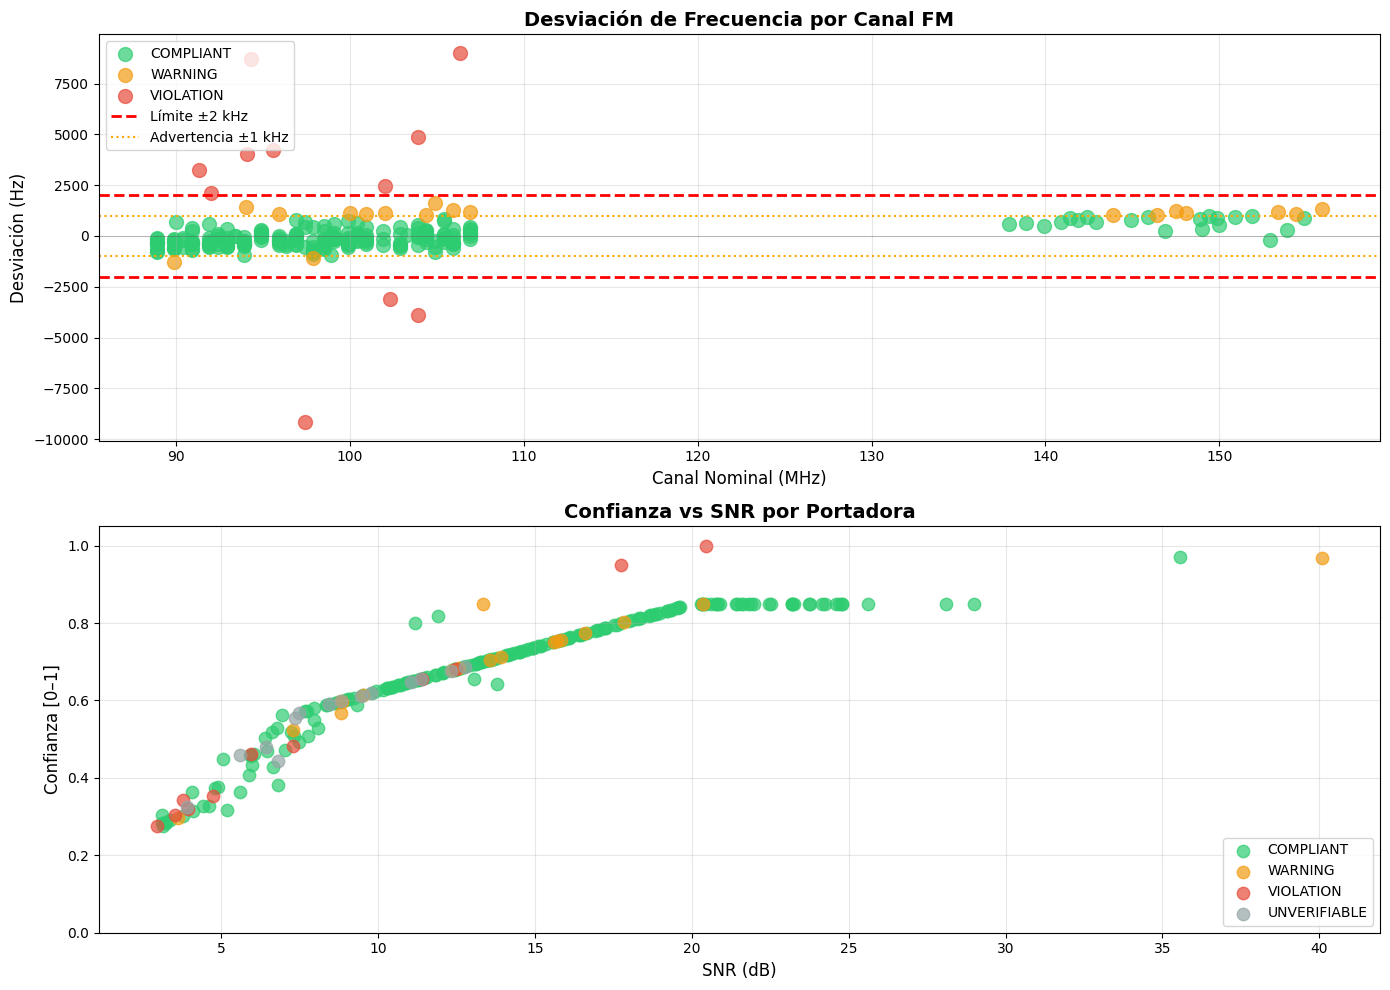

In [16]:
# ── 11 · Visualización con Matplotlib (sin dependencias adicionales) ──────────

import matplotlib.pyplot as plt

if not summary_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # ── 11.1 Desviación por canal (Gráfico de barras) ─────────────────────────
    ax1 = axes[0]
    
    # Agrupar por canal y estado
    for status in ["COMPLIANT", "WARNING", "VIOLATION"]:
        data = summary_df[summary_df["compliance_status"] == status]
        if not data.empty:
            data_sorted = data.sort_values("nominal_mhz")
            color_map = {"COMPLIANT": "#2ecc71", "WARNING": "#f39c12", "VIOLATION": "#e74c3c"}
            ax1.scatter(data_sorted["nominal_mhz"], data_sorted["deviation_hz"], 
                       label=status, color=color_map[status], s=100, alpha=0.7)
    
    # Líneas de tolerancia
    ax1.axhline(y=CFG.tolerance_hz, color='red', linestyle='--', linewidth=2, label=f'Límite ±{CFG.tolerance_hz/1e3:.0f} kHz')
    ax1.axhline(y=-CFG.tolerance_hz, color='red', linestyle='--', linewidth=2)
    ax1.axhline(y=CFG.warning_hz, color='orange', linestyle=':', linewidth=1.5, label=f'Advertencia ±{CFG.warning_hz/1e3:.0f} kHz')
    ax1.axhline(y=-CFG.warning_hz, color='orange', linestyle=':', linewidth=1.5)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    ax1.set_xlabel('Canal Nominal (MHz)', fontsize=12)
    ax1.set_ylabel('Desviación (Hz)', fontsize=12)
    ax1.set_title('Desviación de Frecuencia por Canal FM', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # ── 11.2 Confianza vs SNR (Scatter plot) ──────────────────────────────────
    ax2 = axes[1]
    
    for status in ["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]:
        data = summary_df[summary_df["compliance_status"] == status]
        if not data.empty:
            color_map = {"COMPLIANT": "#2ecc71", "WARNING": "#f39c12", 
                        "VIOLATION": "#e74c3c", "UNVERIFIABLE": "#95a5a6"}
            ax2.scatter(data["snr_db"], data["confidence"], 
                       label=status, color=color_map[status], s=80, alpha=0.7)
    
    ax2.set_xlabel('SNR (dB)', fontsize=12)
    ax2.set_ylabel('Confianza [0–1]', fontsize=12)
    ax2.set_title('Confianza vs SNR por Portadora', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig("fm_carrier_analysis.png", dpi=150, bbox_inches='tight')
    print("\n✅ Gráficas guardadas en: fm_carrier_analysis.png")
    plt.show()

else:
    print("summary_df vacío — sin gráficas.")

Generando visualizaciones...
✅ Gráficas guardadas en: fm_carrier_analysis.png


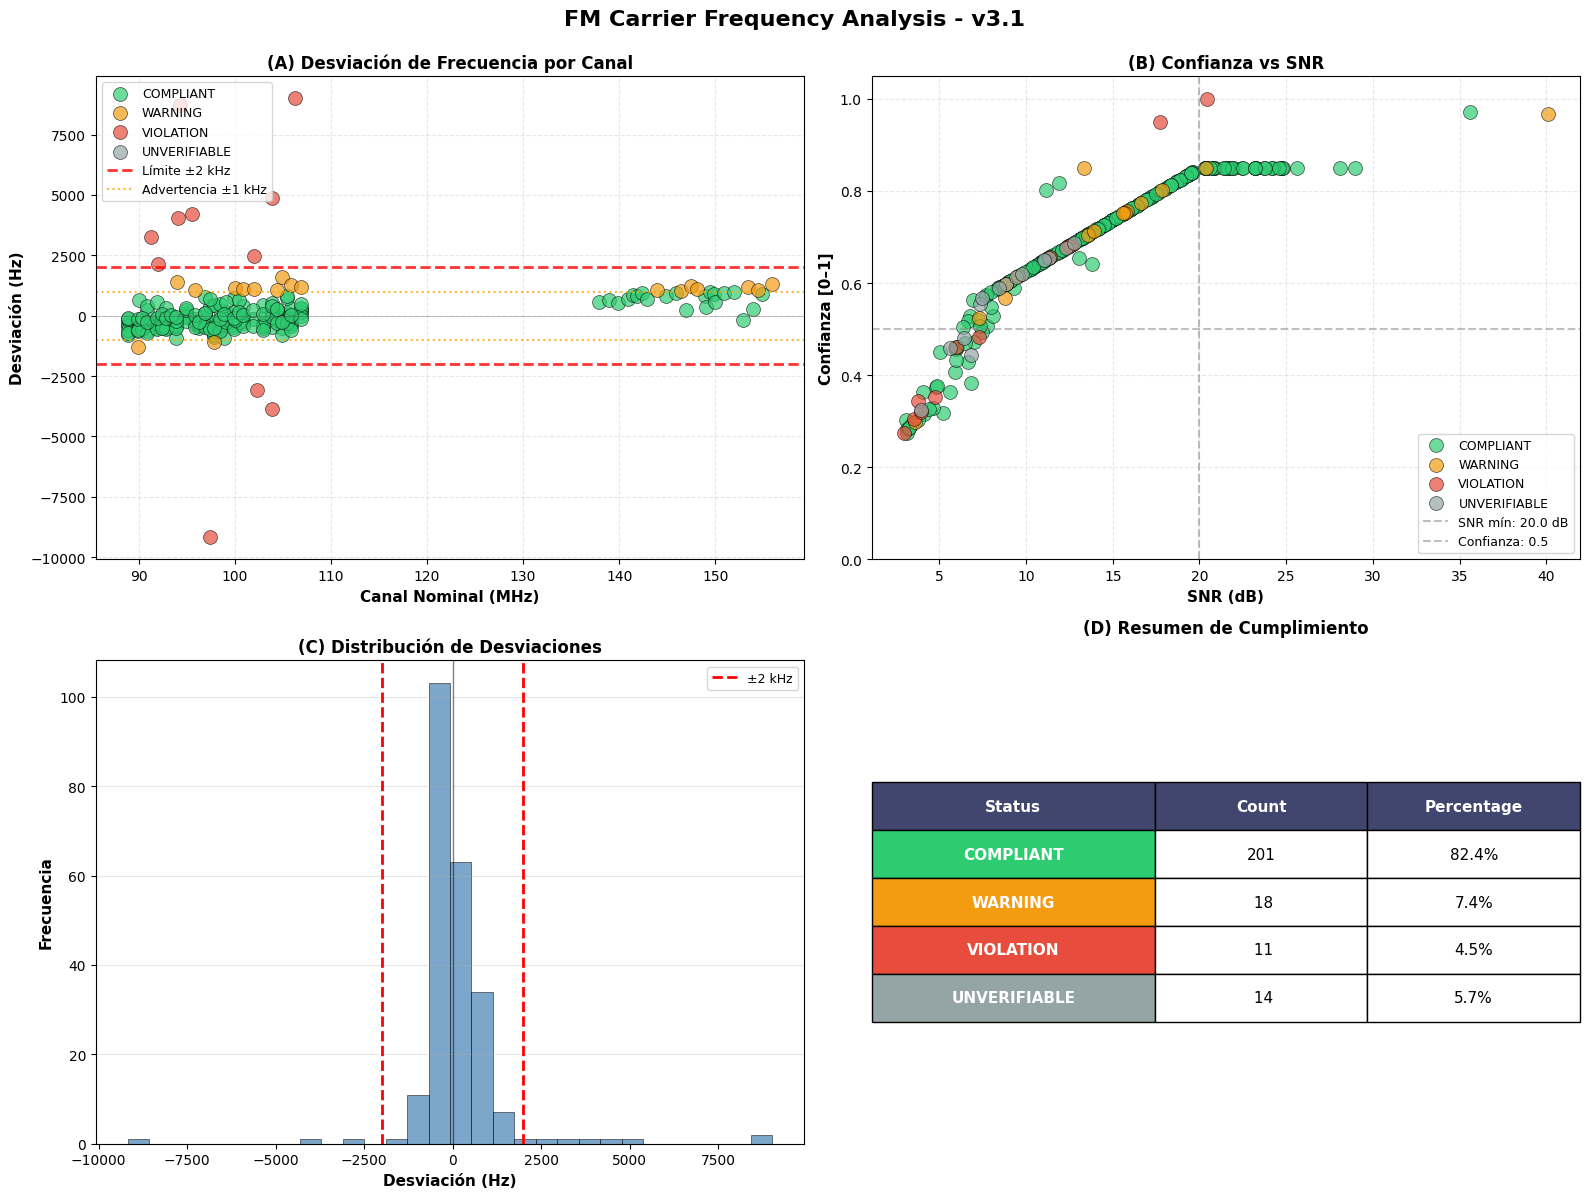

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN CON MATPLOTLIB (Sin Dependencias Adicionales)
# Reemplaza Plotly para evitar problemas de nbformat
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if not summary_df.empty:
    print("Generando visualizaciones...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('FM Carrier Frequency Analysis - v3.1', fontsize=16, fontweight='bold', y=0.995)
    
    # Color map
    color_map = {"COMPLIANT": "#2ecc71", "WARNING": "#f39c12", 
                 "VIOLATION": "#e74c3c", "UNVERIFIABLE": "#95a5a6"}
    
    # ── 1. Desviación por canal (scatter) ─────────────────────────────────────
    ax = axes[0, 0]
    
    for status in ["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]:
        data = summary_df[summary_df["compliance_status"] == status]
        if not data.empty:
            ax.scatter(data["nominal_mhz"], data["deviation_hz"], 
                      label=status, color=color_map[status], s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Líneas de tolerancia
    ax.axhline(y=CFG.tolerance_hz, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Límite ±{CFG.tolerance_hz/1e3:.0f} kHz')
    ax.axhline(y=-CFG.tolerance_hz, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.axhline(y=CFG.warning_hz, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label=f'Advertencia ±{CFG.warning_hz/1e3:.0f} kHz')
    ax.axhline(y=-CFG.warning_hz, color='orange', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    ax.set_xlabel('Canal Nominal (MHz)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Desviación (Hz)', fontsize=11, fontweight='bold')
    ax.set_title('(A) Desviación de Frecuencia por Canal', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # ── 2. Confianza vs SNR ──────────────────────────────────────────────────
    ax = axes[0, 1]
    
    for status in ["COMPLIANT", "WARNING", "VIOLATION", "UNVERIFIABLE"]:
        data = summary_df[summary_df["compliance_status"] == status]
        if not data.empty:
            ax.scatter(data["snr_db"], data["confidence"], 
                      label=status, color=color_map[status], s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    ax.axvline(x=CFG.min_snr_full_db, color='gray', linestyle='--', alpha=0.5, label=f'SNR mín: {CFG.min_snr_full_db} dB')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Confianza: 0.5')
    
    ax.set_xlabel('SNR (dB)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Confianza [0–1]', fontsize=11, fontweight='bold')
    ax.set_title('(B) Confianza vs SNR', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    
    # ── 3. Distribución de desviaciones ──────────────────────────────────────
    ax = axes[1, 0]
    
    valid_dev = summary_df[summary_df["deviation_hz"].notna()]["deviation_hz"].values
    if len(valid_dev) > 0:
        ax.hist(valid_dev, bins=30, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(x=CFG.tolerance_hz, color='red', linestyle='--', linewidth=2, label=f'±{CFG.tolerance_hz/1e3:.0f} kHz')
        ax.axvline(x=-CFG.tolerance_hz, color='red', linestyle='--', linewidth=2)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Desviación (Hz)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
    ax.set_title('(C) Distribución de Desviaciones', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # ── 4. Tabla de resumen de cumplimiento ────────────────────────────────
    ax = axes[1, 1]
    ax.axis('off')
    
    # Crear tabla de cumplimiento
    compliance_counts = summary_df["compliance_status"].value_counts().to_dict()
    summary_data = [
        ["COMPLIANT", f"{compliance_counts.get('COMPLIANT', 0):>3}", f"{100*compliance_counts.get('COMPLIANT', 0)/max(1,len(summary_df)):.1f}%"],
        ["WARNING", f"{compliance_counts.get('WARNING', 0):>3}", f"{100*compliance_counts.get('WARNING', 0)/max(1,len(summary_df)):.1f}%"],
        ["VIOLATION", f"{compliance_counts.get('VIOLATION', 0):>3}", f"{100*compliance_counts.get('VIOLATION', 0)/max(1,len(summary_df)):.1f}%"],
        ["UNVERIFIABLE", f"{compliance_counts.get('UNVERIFIABLE', 0):>3}", f"{100*compliance_counts.get('UNVERIFIABLE', 0)/max(1,len(summary_df)):.1f}%"],
    ]
    
    table = ax.table(cellText=summary_data,
                    colLabels=["Status", "Count", "Percentage"],
                    cellLoc='center',
                    loc='center',
                    colWidths=[0.4, 0.3, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Color header
    for i in range(3):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color rows
    colors = ["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"]
    for idx, color in enumerate(colors, 1):
        table[(idx, 0)].set_facecolor(color)
        table[(idx, 0)].set_text_props(weight='bold', color='white')
    
    ax.set_title('(D) Resumen de Cumplimiento', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    # Save figure (if export_dir is defined from execution cell)
    try:
        fig_path = export_dir / "05_analysis_plot.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        logger.info(f"Plot saved: {fig_path}")
        print(f"✅ Gráficas guardadas en: {fig_path}")
    except NameError:
        # export_dir not defined (cell run independently)
        fig_path = Path("fm_carrier_analysis.png")
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"✅ Gráficas guardadas en: {fig_path}")
    
    plt.show()
    plt.close()

else:
    print("⚠️  summary_df vacío — sin gráficas.")


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c71e238e-fa4e-44ac-af7f-d29021a4ac02' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>